In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# FindContours de cv2 pour détecter la ligne pleurale (généralement la ligne la plus grande et la plus en bas) + remplacer les bords de l'image par des pixels noirs 

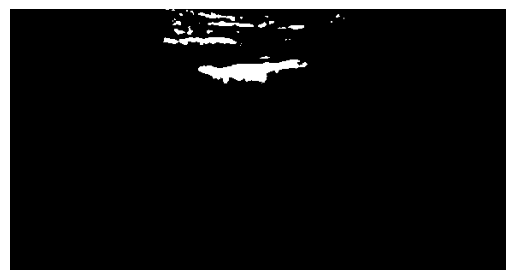

In [7]:
image = cv2.imread('Patients/Patients/20Patient 1LC20/1020M0/201902/2019010K.jpg', cv2.IMREAD_GRAYSCALE)

margin = 50
height, width = image.shape[:2]

cropped_image = image[margin:height-margin, margin:width-margin]

_, binary_image = cv2.threshold(cropped_image, 150, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = np.zeros_like(cropped_image)

cv2.drawContours(output, contours, -1, (255), thickness=cv2.FILLED)

plt.imshow(output, cmap='gray')
plt.axis('off')
plt.show()


# FindContour + recadrage de l'image en dessous de la ligne pleurale + test de plusieurs seuils pour essayer de trouver les lignes B

Fonctionne sur les images avec un fort contraste lumineux au niveau des lignes B, car c'est une méthode simple.

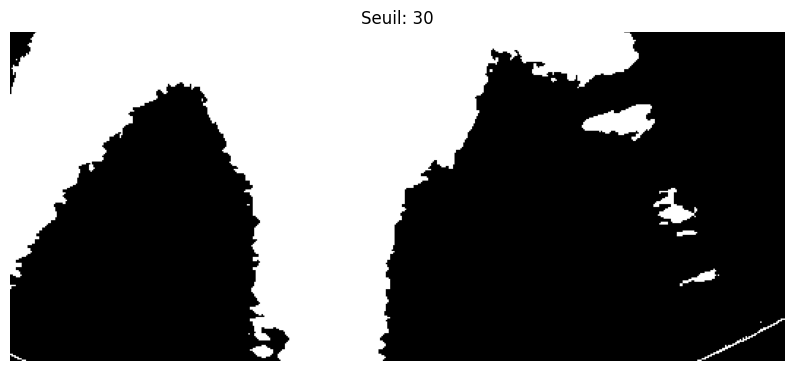

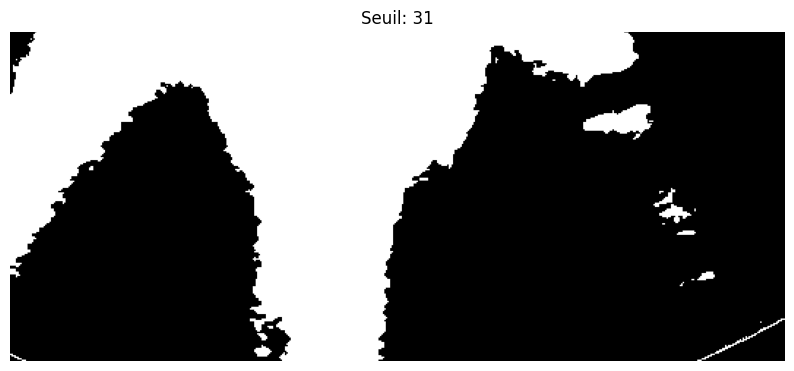

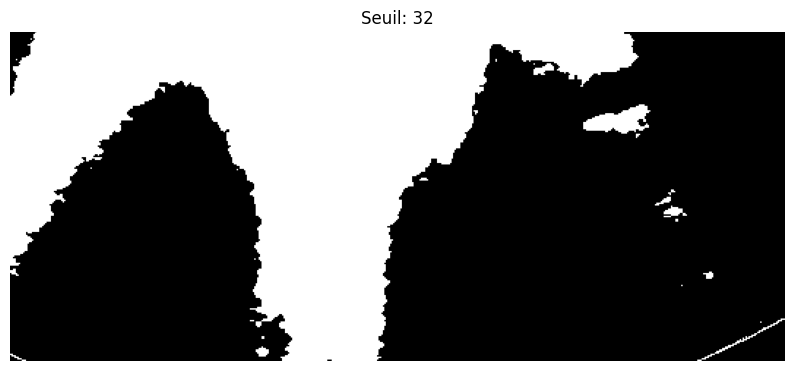

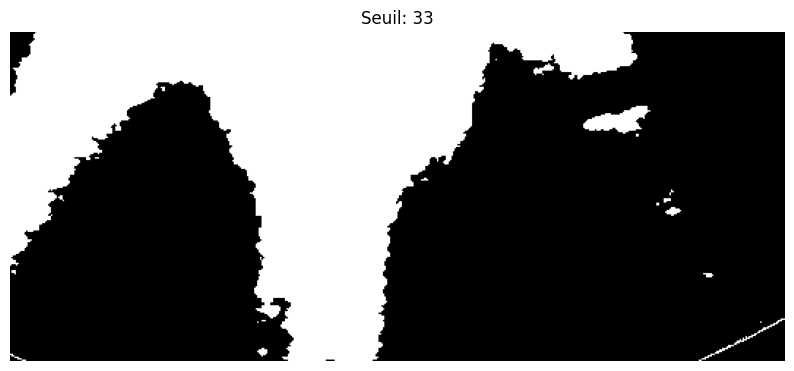

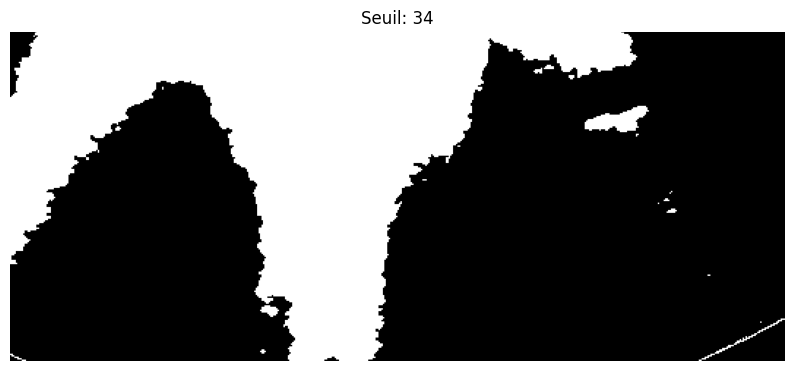

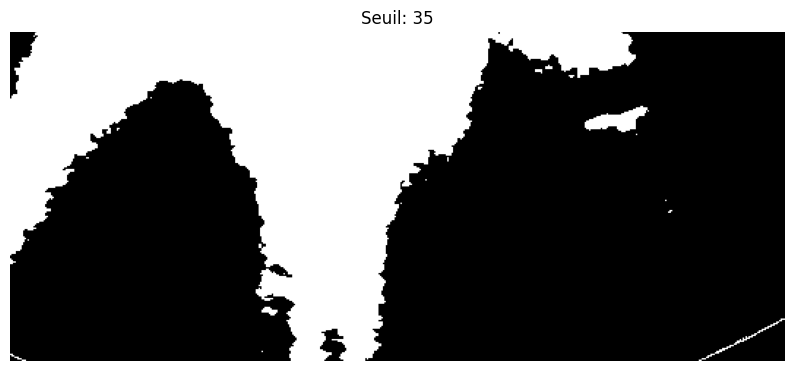

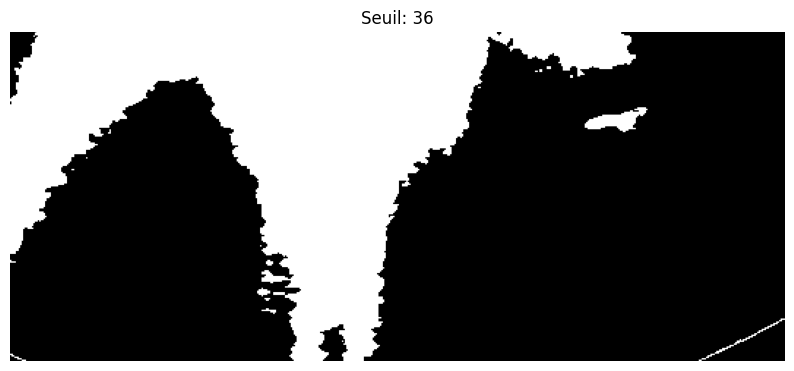

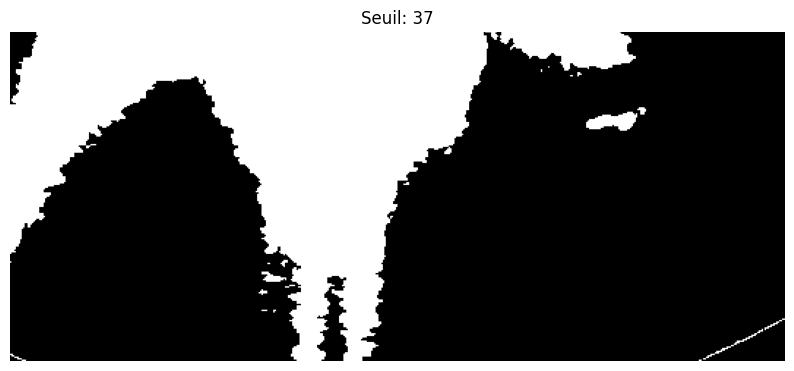

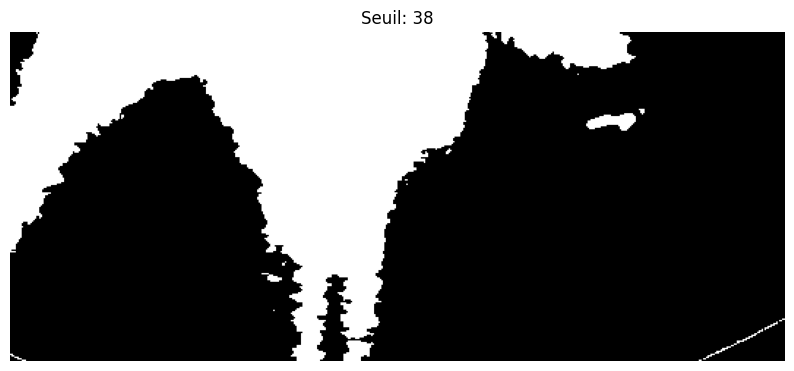

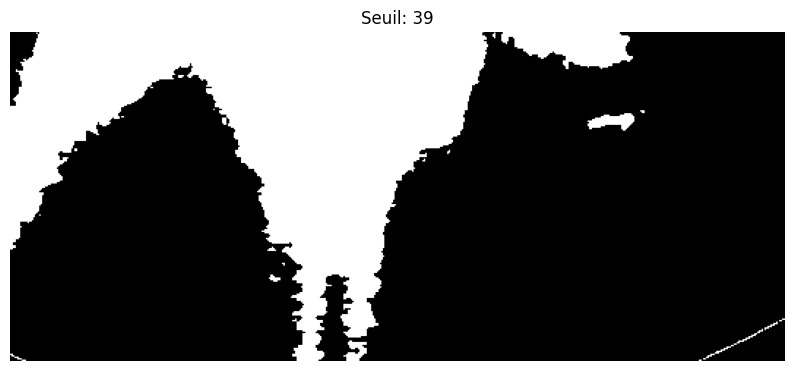

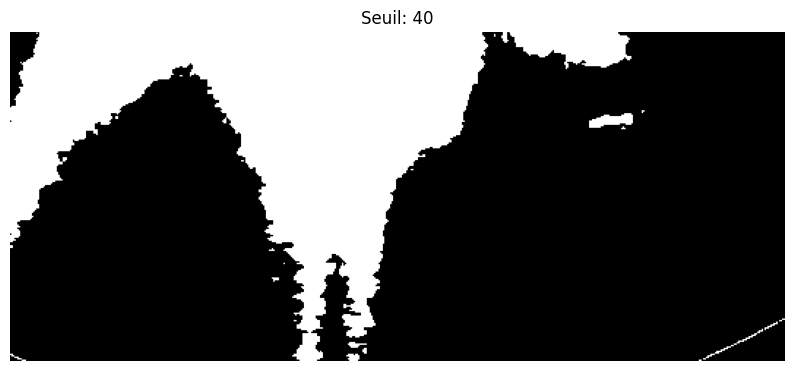

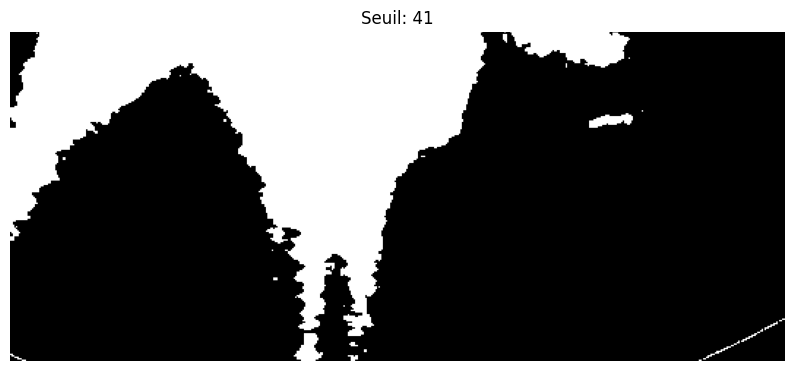

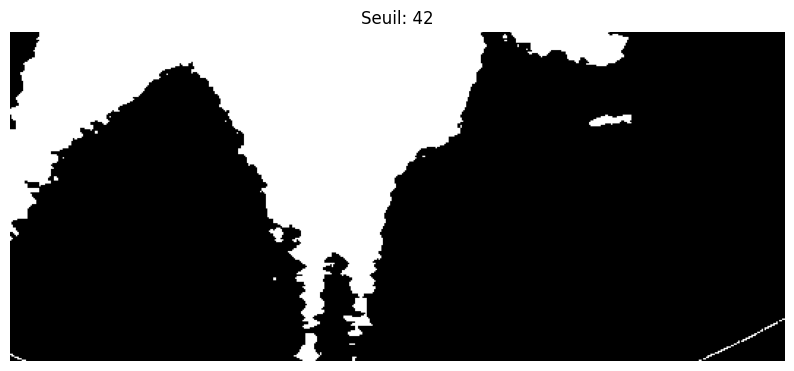

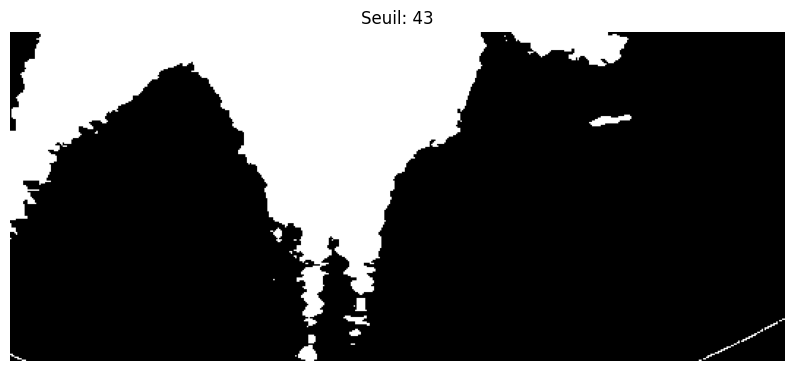

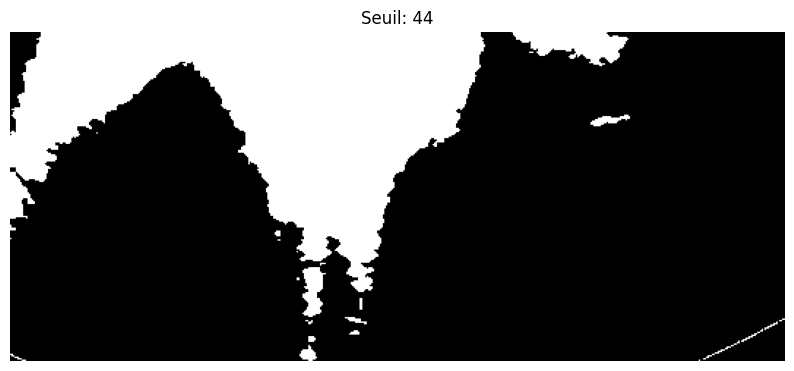

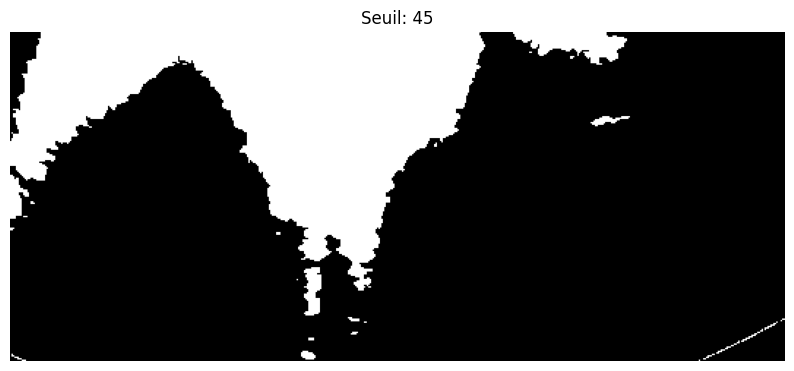

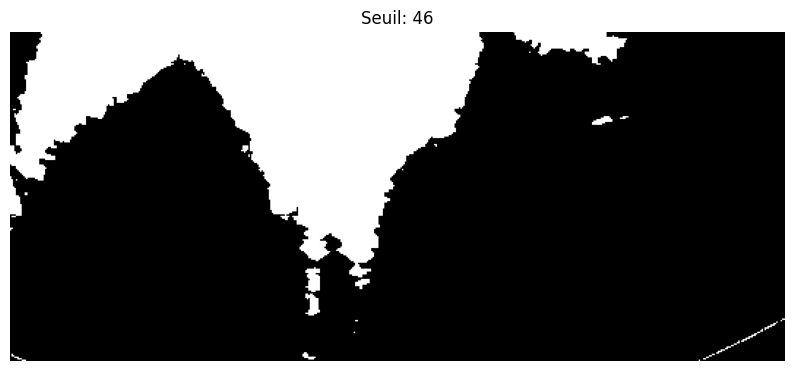

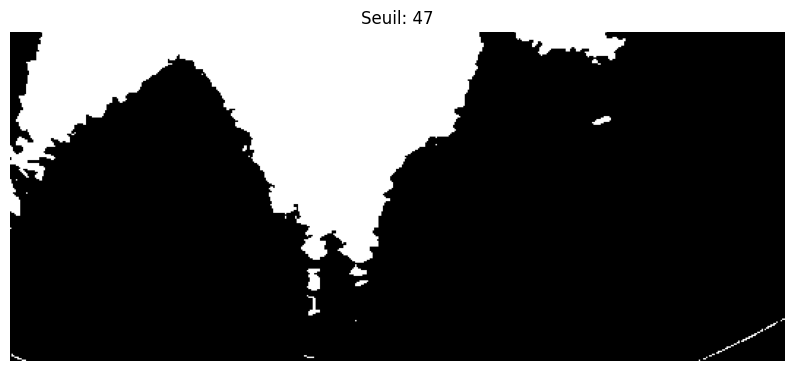

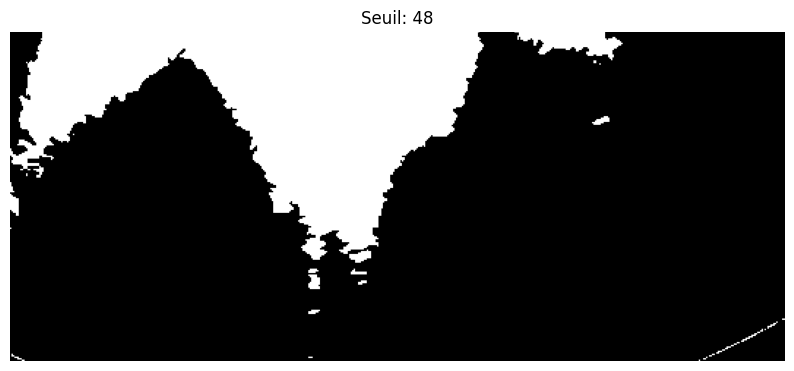

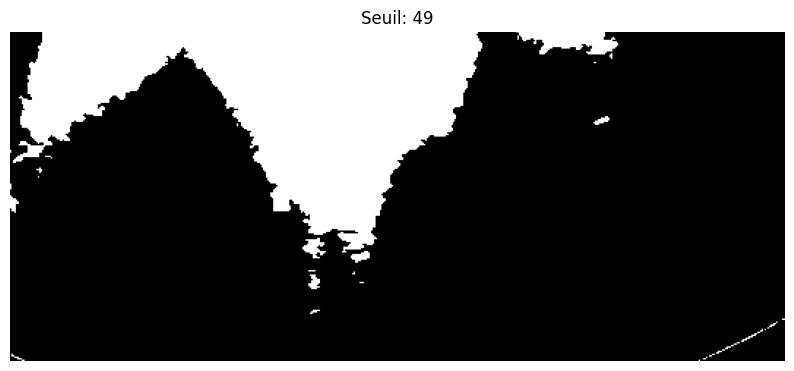

In [8]:
image = cv2.imread('Patients/Patients/20Patient 1LC20/1020M0/201902/2019010K.jpg', cv2.IMREAD_GRAYSCALE)

margin = 50 
height, width = image.shape[:2]

cropped_image = image[margin:height-margin, margin:width-margin]

equalized_image = cv2.equalizeHist(cropped_image)

blurred_image = cv2.GaussianBlur(equalized_image, (5, 5), 0)

binary_image = cv2.adaptiveThreshold(blurred_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest_contour = max(contours, key=cv2.contourArea)

    pleural_line_image = np.zeros_like(cropped_image)
    cv2.drawContours(pleural_line_image, [largest_contour], -1, (255), thickness=cv2.FILLED)

    pleural_line_y = int(np.mean(largest_contour[:, :, 1]))

    below_pleural_line = cropped_image[pleural_line_y:height-margin, margin:width-margin]

    for threshold in range(30, 50, 1):
        _, binary_below = cv2.threshold(below_pleural_line, threshold, 255, cv2.THRESH_BINARY)

        contours_below, _ = cv2.findContours(binary_below, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        output_below = np.zeros_like(below_pleural_line)

        cv2.drawContours(output_below, contours_below, -1, (255), thickness=cv2.FILLED)

        plt.figure(figsize=(10, 5))
        plt.imshow(output_below, cmap='gray')
        plt.title(f'Seuil: {threshold}')
        plt.axis('off')
        plt.show()
else:
    print("Aucun contour trouvé.")
